## Homework 6 - due Friday, April 3 by 4 PM 

Name: Kristen Townsend

In [1]:
# Use this cell to import all necessary packages for the assignment 
import numpy as np
import matplotlib.pyplot as plt

### Problem 1: Exercise 6.1, page 220

Part 1

Equations for all the junctions:

$V_1: 4V_1 - V_2 - V_3 - V_4 = V_+$\
$V_2: -V_1 + 3V_2 - V_4 = 0$\
$V_3: -V_1 + 3V_3 - V_4 = V_+$\
$V_4: -V_1 - V_2 - V_3 + 4V_4 = 0$

Each equation was found by following the calculation of $V_1$ shown in the book $\left(\frac{V_1 - V_2}{R} + \frac{V_1 - V_3}{R} + \frac{V_1 - V_4}{R} + \frac{V_1 - V_+}{R} = 0 \right)$ and simplifying. The relation between each connected junction is given by Ohm's Law.

The constants of each voltage can be placed into a matrix, and, using one of the following methods, can be used to determine the value of each voltage.

In [ ]:
# part 2
# defining the function
def Gauss_Elim(A,x,v):
    # pivoting
    for m in range(N):
        # find the row with the largest pivot element is
        pivot = m
        largest = np.abs(A[m,m])
        for i in range(m+1,N):
            if np.abs(A[i,m]) > largest:
                largest = np.abs(A[i,m])
                pivot = i

        # swap rows
        for j in range(N):
            A[m,j], A[pivot,j] = A[pivot,j], A[m,j]
        v[m], v[pivot] = v[pivot], v[m]

        # gaussian elimination with backsubtitution 

        for k in range(N):
            # divide by diagonal elements
            div = A[k,k]
            A[k,:] /= div
            v[k] /= div
            
            # subtract from lower rows
            for i in range(k+1,N):
                mult = A[i,k]
                A[i,:] -= mult*A[k,:]
                v[i] -= mult*v[k]

    # apply backsubstitution
    for m in range(N-1,-1,-1): # start at the end, move at one step to zero
        x[m] = v[m]
        for i in range(m+1,N):
            x[m] -= A[m,i]*x[i]

    return(x)

# defining constant
Vplus = 5.0 # volts
Vend = 0.0 # volts


# define matrix & vectors 
A = np.array([[4, -1, -1, -1],
             [-1,  3,  0, -1],
             [-1,  0,  3, -1], 
             [-1, -1, -1,  4]], float)
v = np.array([Vplus, Vend, Vplus, Vend], float)

# determine the number of variables solving for
N = len(v)
# create array for results, x
x = np.zeros(N, float)
#print(A)

# run the function
Gauss_Elim(A,x,v)

# print results
print("Resulting values (using Gaussian Elimination) for V1, V2, V3, and V4:")
print("V1:", round(x[0], 2), "Volts")
print("V2:", round(x[1], 2), "Volts")
print("V3:", round(x[2], 2), "Volts")
print("V4:", round(x[3], 2), "Volts")


Resulting values (using Gaussian Elimination) for V1, V2, V3, and V4:
V1: 3.0 Volts
V2: 1.67 Volts
V3: 3.33 Volts
V4: 2.0 Volts


##### Explanation: 

The solution to the system of equations found in part (a) is determined using gaussian elimination with pivoting. Gaussian Elimination works by doing gradual transformations on the equations that do not change the solution to systematically eliminate the lower-diagonal coefficients. This eventually creates easily solvable equations that can be plugged into each other to find a result for each unknown variable.

Physically, these results do make sense. The junctions closest to the voltage source have higher voltages than those further away. The value of the voltages at the junctions is not increasing beyond the initial 5 volts, which I beleive shows that the equations are set up properly. V3 has the most voltage at its respective junction. This makes sense as it is both close to the source and is connected to fewer junctions to pass the current along. V2 has the least amount of voltage at its respective junction. It is placed following a junction that has many offshoots to pass current along and 'dilute' the voltage.

### Problem 2: Exercise 6.4, page 228

In [4]:
# defining constant
Vplus = 5.0 # volts
Vend = 0.0 # volts

# define matrix & vectors 
A = np.array([[4, -1, -1, -1],
             [-1,  3,  0, -1],
             [-1,  0,  3, -1], 
             [-1, -1, -1,  4]], float)
v = np.array([Vplus, Vend, Vplus, Vend], float)

# determine the number of variables solving for
N = len(v)
# create array for results
x = np.linalg.solve(A,v)

# print results
print("Resulting values (using LU Decomposition) for V1, V2, V3, and V4:")
print("V1:", round(x[0], 2), "Volts")
print("V2:", round(x[1], 2), "Volts")
print("V3:", round(x[2], 2), "Volts")
print("V4:", round(x[3], 2), "Volts")

Resulting values (using LU Decomposition) for V1, V2, V3, and V4:
V1: 3.0 Volts
V2: 1.67 Volts
V3: 3.33 Volts
V4: 2.0 Volts


#### Explanation: 

This excercise uses the same basic set-up as the previous problem. The same matrix is used, but results are found using numpy.linalg.solve() to apply LU Decomposition to the original matrix.

LU Decomposition works by separating the computationally exhausing factorization process on the matrix from the actual solving using the factored form and the right side of the equation. This is more efficient than Gaussian Elimination.

I got the same results each time. The physical logic begind each value still holds from exercise $6.1$.


### Problem 3: Exercise 6.11, page 260

In [5]:
# part 1
# define the function
def f(x):
    return 1 - np.exp(-c*x)

# defining constant
c = 2

N = 50 # number of iterations
x = 1 # initial guess
print(x)

for i in range(N):
    x = f(x)
    print(x)
    if round(x,7) == round(f(x),7):
        # one more time for good measure
        x = f(x)
        print("Desired accuracy reached")
        break

# print results
print("x =", round(x,6))
        

1
0.8646647167633873
0.8225966691808597
0.8070247503317746
0.8009201942366403
0.7984747083247583
0.7974866394625985
0.797086049491047
0.796923413762181
0.7968573480008734
0.7968305046795713
0.7968195968986895
0.7968151643557075
0.7968133630966887
0.7968126311118457
0.7968123336514794
0.7968122127708882
Desired accuracy reached
x = 0.796812


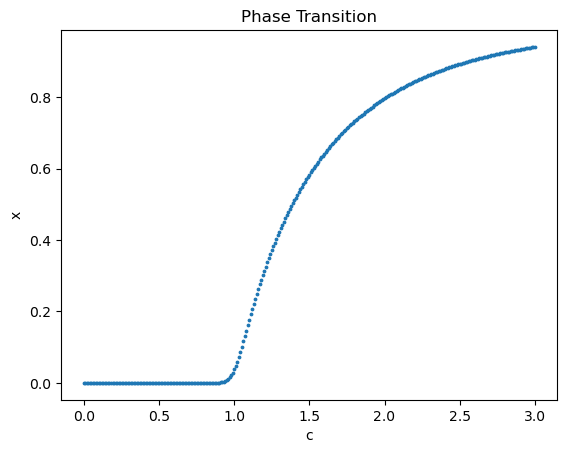

In [6]:
# part 2
# define the function
def f(x,c):
    return 1 - np.exp(-c*x)

# defining constant
c = np.arange(0, 3.01, 0.01)
xpts = np.zeros(len(c))

N = 50 # number of iterations


for i in range(len(c)):
    x = 1 # initial guess

    # relaxation method
    for j in range(N):
        x = f(x,c[i])
        #print(x)
        xpts[i] = x


# plot results
plt.scatter(c, xpts, s=3)
plt.xlabel("c")
plt.ylabel("x")
plt.title("Phase Transition")

plt.show()


#### Explanation: 

Part (a) required the use of the relaxation method with a single variable to solve the equation $x=1-e^{-cx}$. The Relaxation Method takes initial guesses for unknown values and plugs the value into the right hand side of the equation. If the resulting value from the right hand side is not the same value as what was inputted, the left hand value is then taken and plugged into the right hand size. This process continues until the solution 'relaxes' into a value.

To save computing power I included a check that breaks the loop of value relaxing once the desired accuracy has been reached and remains consistent. 

For part (b) I modified the function to take the constant $c$ as an input value and created an array of values of $c$ to test. A nested for loop to perform the relaxation method on each value of $c$, and the results were plotted above. The plot shows a transition where $x=0$ and where $x$ becomes non-zero once $c$ becomes greater than $1$. 

### Problem 4: Exercise 6.14, page 266

To find where the emitted radiation given by the equation $I(\lambda) = {2\pi h c^2 \lambda^{-5}} / {e^{hc/\lambda k_BT}-1}$, I first found the derivative and set it equal to zero. This gives the following:

$$ 5e^{-hc/{\lambda k_BT}} + hc/{\lambda k_BT} - 5 = 0. $$

By using the substitution $ x = hc/\lambda k_B T $, I was then able to solve for $\lambda$ to then get the relation 


$$\lambda=\frac{hc}{k_B x T}$$


The $x$ substitution gives $5e^{-x}+x-5=0$.

Substituting in the Wien displacement constant $b = {hc}/{k_Bx}$ where $x$ is the solution to the equation above results in the following Wien displacement law:


$$\lambda=\frac{b}{T}$$

This leaves $\lambda$ as the solution to the initial equation, and shows the maximum wavelength obeys this law.


In [7]:
# part b
# define function
def f(x):
    return 5*np.exp(-x) + x - 5

def binary_solve(x1, x2, f, accuracy):
    f1 = f(x1)
    f2 = f(x2)

    if f1 * f2 < 0:
        while np.abs(x2 - x1) > accuracy:
            xp = 0.5*(x2+x1)
            fp = f(xp)
            if fp*f1 > 0:
                x1, f1 = xp, fp
            else:
                x2, f2 = xp, fp
        result = 0.5 * (x1 + x2)
    else:
        result = -999.99
    
    return result

# defining constants
h = 6.62607015e-34 # Plank's constant
c = 299792458 # speed of light
kB = 1.380649e-23 # Boltzmann's constant

# initial guesses & accuracy
x1 = 2.0
x2 = 6.0
target = 1e-6

# call function
x_answer = binary_solve(x1,x2,f,target)
#print(x_answer)

# finding displacement constant
disp_const = (h * c) / (kB * x_answer)
#print(disp_const)

print("Wien displacement constant:", round(disp_const,6))

Wien displacement constant: 0.002898


In [8]:
# part c
wavelength = 502e-9 # meters

# finding the temperature of the sun
sun_temp = disp_const / wavelength

print("The surface of the Sun is approximately", round(sun_temp), "Kelvin")

The surface of the Sun is approximately 5772 Kelvin


#### Explanation: 

One thing I noticed for part (a) was that the equations used sort of substitute in a loop. That's pretty cool, but also a bit weird.

Part (b) uses the binary search method on nonlinear equation $5e^{-x} + x -5 = 0$. The binary search method works by taking the initial guesses of $x_1$ and $x_2$ and first ensuring $f(x_1)$ and $f(x_2)$ have opposite signs and are on either side of the solution. The main purpose of the function defined is to calculate the midpoint $x'$ between $x_1$ and $x_2$ and, depending on the sign of $f(x')$, update the initial point with the same sign to be $x'$. If the distance between the two points being tested is greater than the target accuracy, the process is repeated. Otherwise it finds the midpoint one more time and returns it as the solution.

Once the solution has been found, the value for $x$ is then plugged into the relation for the Wien displacement constant $b = hc/k_Bx$ to find a value for the constant.

The actual value of the displacement constant (as found on the internet) is 2.897771955e-3. The value I calculated is accurate to 10e-6, as required.

Part (c) simply uses the Wien displacement law formula $\lambda = b/T$. The relations is reshaped to equal T, and the previously determined displacement constant $b$ and the wavelength peak $\lambda = 502$ nm are entered into $T = b/\lambda$.

The surface of the sun, according to the internet, is approximately 5700 to 5800 Kelvin. My result of 5772 Kelvin fits within this range!

### Problem 5: 

Part (a)

Take the partial derivatives of:
$$ U(x,y) = x^4 + y^4 - 2x^2 - 4y^2 + xy + 5x $$

The partial derivative relative to $x$ is $ dU_x = 4x^3 - 4x + y + 5 $. This will serve as my $f(x,y)$ equation in part (c).

The partial derivative relative to $y$ is $ dU_y = 4y^3 - 8y + x $. This will serve as my $g(x,y)$ equation in part (c).

These functions will be used with Newton's Method to determine where the gradient of $U(x,y)$ is equal to zero.

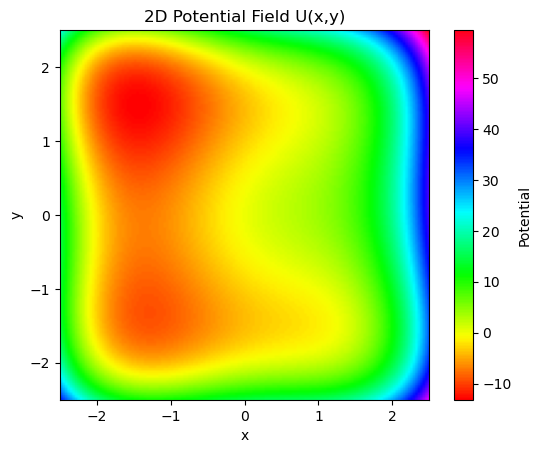

In [9]:
# part b
# define the function U(x,y)
def U(x,y):
    return x**4 + y**4 - 2*x**2 - 4*y**2 + x*y + 5*x

# values for x, y grid
side = 2.5 #meters
N = 150

x = np.linspace(-side, side, N)
y = np.linspace(-side, side, N)

# mesh into one grid
X,Y = np.meshgrid(x,y)

# evaluate the funciton on the grid
potential = U(X,Y)

# plotting details
plt.imshow(potential, origin="lower", extent=[-side,side,-side,side], cmap="hsv") 
plt.colorbar(label="Potential")
plt.xlabel('x')
plt.ylabel('y')
plt.title("2D Potential Field U(x,y)")
plt.show()


In [11]:
# part c
# defining functions as partial derivatives of U(x,y)
def f(x,y):
    return 4*x**3 - 4*x + y + 5

def g(x,y):
    return 4*y**3 - 8*y + x

# initial guess number
x = -1.5
y = 1.5

# define variables
accuracy = 1e-10
err = 0.5
while err > accuracy:
    # partials to fill Jacobian
    a = 12*x**2 - 4
    b = 1
    c = 1
    d = 12*y**2 - 8

    J = np.array([[a,b],
                  [c,d]], float)
    v = np.array([f(x,y), g(x,y)], float)
    values = np.linalg.solve(J,v)
    # determine new values
    x -= values[0]
    y -= values[1]

    # calculate new error
    err = np.sqrt(values[0]**2 + values[1]**2)

# printing results
x_fin = round(x,5)
y_fin = round(y,5)

print(f'Stable equilibrium point at ({x_fin}, {y_fin}).')

Stable equilibrium point at (-1.45484, 1.49762).


#### Explanation: 

For part (b) I made a density plot of $U(x,y)$ by using the defined function $ U(x,y) = x^4 + y^4 - 2x^2 - 4y^2 + xy + 5x $ over a meshed grid. The goal of this is to find where both $dU_x$ and $dU_y$ are equal to zero, as that is where a stable equilibrium point occurs.

Over a large area, the density plot appears to form a nearly bowl-like depression with a slightly deeper side in the $-x$ direction. I had to experiment with the scale quite a bit to properly view the location of potential minima.

I was also having some difficulty with having the axis' show the distance instead of the number of points along each side, but I discovered the extent attribute of the function plt.imshow() and was able to specify the values shown along the axis.

Strong candidates are at $(-1.5,1.5)$ and $(-1.5,-1.5)$. The depression at $(-1.5,1.5)$ appears to be ever so slightly deeper, so I am assuming it is the region of the stable equilibrium point. I will be using it as my initial guess for part (c).


For part (c), the following equations are needed to use Newton's method to solve for variables $x$ and $y$:

$$ f(x,y) = 4x^3 - 4x + y + 5 \qquad g(x,y) = 4y^3 - 8y + x $$
$$\frac{\partial}{\partial x} f(x,y) = 12x^2 - 4 $$
$$\frac{\partial}{\partial y} f(x,y) = 1 $$
$$\frac{\partial}{\partial x} g(x,y) = 1 $$
$$\frac{\partial}{\partial y} g(x,y) = 12y^2 - 8 $$

I then defined the my initial guesses for the values of x and y, and the initial error. I also defined my desired accuracy to be 1e-10.

Within a while loop I set up a Jacobian matrix $J$ using the derivative functions defined above and the values within $v$ as the original functions found in part (a).

I was then able to use linalg.solve() to compute the eigen values that susteined the relationship between J and v, which eventually became my solution once the error was smaller than the desired accuracy.